**Manual Prediction test**

In [1]:
import torch
import timm

CLASSES = [
    "AK",
    "BCC",
    "BKL",
    "DF",
    "MEL",
    "NV",
    "SCC",
    "VASC"
]

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=False,
    num_classes=8
)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/DermaVision/models/swin_tiny_best.pth",
        map_location=DEVICE
    )
)

model.eval()

print("Model Loaded Successfully")

Model Loaded Successfully


In [2]:
!pip install -q timm
!pip install -q pillow
!pip install -q matplotlib

In [3]:
import torch
import timm
import json
import numpy as np

from PIL import Image

import matplotlib.pyplot as plt

from torchvision import transforms

In [4]:
with open(
    "/content/drive/MyDrive/DermaVision/artifacts/label_mapping.json",
    "r"
) as f:

    idx2label = json.load(f)

print(idx2label)

{'0': 'AK', '1': 'BCC', '2': 'BKL', '3': 'DF', '4': 'MEL', '5': 'NV', '6': 'SCC', '7': 'VASC'}


In [5]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

Device: cuda


In [6]:
model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=False,
    num_classes=8
)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/DermaVision/models/swin_tiny_best.pth",
        map_location=DEVICE
    )
)

model = model.to(DEVICE)

model.eval()

print("Model Loaded Successfully")

Model Loaded Successfully


In [7]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [10]:
from google.colab import files

uploaded = files.upload()

Saving ISIC_0000001.jpg to ISIC_0000001.jpg


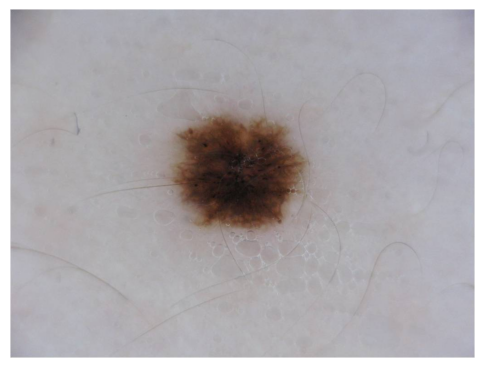

In [11]:
image_path = list(uploaded.keys())[0]

image = Image.open(
    image_path
).convert("RGB")

plt.figure(figsize=(6,6))

plt.imshow(image)

plt.axis("off")

plt.show()

In [12]:
def predict_image(image_path):

    image = Image.open(
        image_path
    ).convert("RGB")

    img_tensor = transform(
        image
    ).unsqueeze(0)

    img_tensor = img_tensor.to(
        DEVICE
    )

    with torch.no_grad():

        outputs = model(
            img_tensor
        )

        probs = torch.softmax(
            outputs,
            dim=1
        )

    confidence, pred_idx = torch.max(
        probs,
        dim=1
    )

    pred_class = idx2label[
        str(pred_idx.item())
    ]

    return (
        pred_class,
        confidence.item(),
        probs.cpu().numpy()[0]
    )

In [13]:
prediction, confidence, probs = predict_image(
    image_path
)

print(
    f"Prediction : {prediction}"
)

print(
    f"Confidence : {confidence:.4f}"
)

Prediction : NV
Confidence : 0.8688


In [14]:
for i, score in enumerate(probs):

    print(
        f"{idx2label[str(i)]:<5}"
        f" : {score*100:.2f}%"
    )

AK    : 1.70%
BCC   : 2.07%
BKL   : 0.83%
DF    : 1.67%
MEL   : 3.69%
NV    : 86.88%
SCC   : 1.61%
VASC  : 1.55%


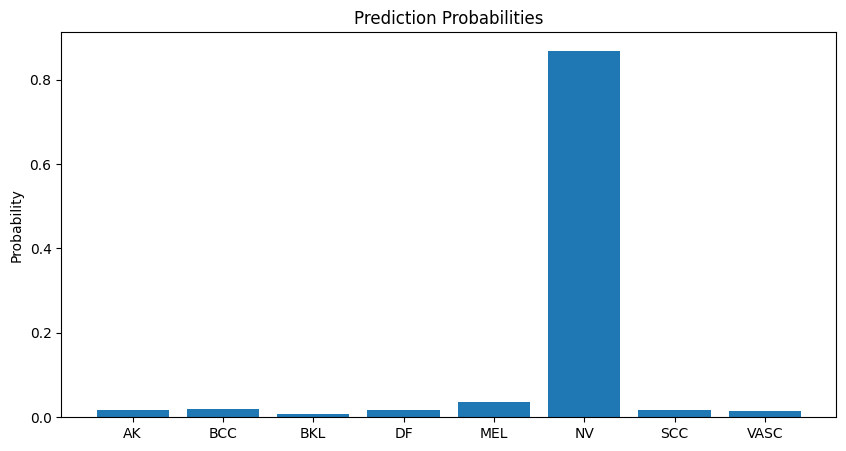

In [15]:
labels = [
    idx2label[str(i)]
    for i in range(8)
]

plt.figure(figsize=(10,5))

plt.bar(
    labels,
    probs
)

plt.title(
    "Prediction Probabilities"
)

plt.ylabel(
    "Probability"
)

plt.show()

In [16]:
report = f"""
Prediction : {prediction}

Confidence : {confidence:.4f}

Probabilities

"""

for i, score in enumerate(probs):

    report += (
        f"{idx2label[str(i)]}"
        f" : {score*100:.2f}%\n"
    )

with open(
    "/content/drive/MyDrive/DermaVision/results/reports/latest_prediction.txt",
    "w"
) as f:

    f.write(report)

print(
    "Prediction Report Saved"
)

Prediction Report Saved


**Grad-CAM Explainability**

In [17]:
!pip install -q grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 59.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [18]:
from pytorch_grad_cam import GradCAM

from pytorch_grad_cam.utils.image import (
    show_cam_on_image
)

import cv2
import numpy as np

In [19]:
print(model)

SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU(approximate='none')
            (drop1): 

In [20]:
target_layers = [
    model.layers[-1].blocks[-1].norm2
]

In [21]:
def reshape_transform(
    tensor,
    height=7,
    width=7
):

    result = tensor.reshape(
        tensor.size(0),
        height,
        width,
        tensor.size(2)
    )

    result = result.transpose(
        2,
        3
    ).transpose(
        1,
        2
    )

    return result

In [22]:
cam = GradCAM(
    model=model,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

In [23]:
image = Image.open(
    image_path
).convert("RGB")

rgb_img = np.array(
    image.resize((224,224))
)

rgb_img = rgb_img.astype(
    np.float32
) / 255.0

input_tensor = transform(
    image
).unsqueeze(0).to(
    DEVICE
)

In [24]:
grayscale_cam = cam(
    input_tensor=input_tensor
)

grayscale_cam = grayscale_cam[0]

visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

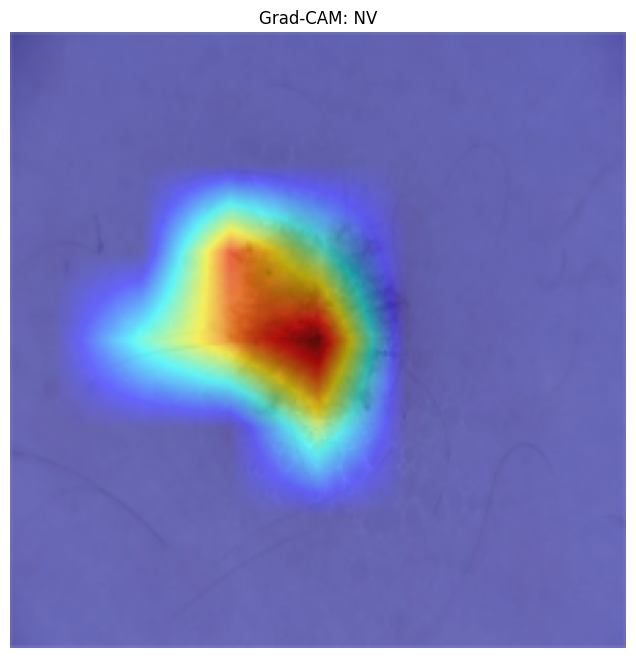

In [25]:
plt.figure(figsize=(8,8))

plt.imshow(
    visualization
)

plt.axis("off")

plt.title(
    f"Grad-CAM: {prediction}"
)

plt.show()

In [26]:
save_path = (
    "/content/drive/MyDrive/DermaVision/"
    "results/plots/latest_heatmap.png"
)

Image.fromarray(
    visualization
).save(save_path)

print("Saved:", save_path)

Saved: /content/drive/MyDrive/DermaVision/results/plots/latest_heatmap.png


**Clinical PDF Report Generator**

In [27]:
!pip install -q reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.6 MB/s eta 0:00:00


In [28]:
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Image as PDFImage
)
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib import colors
from datetime import datetime

In [29]:
original_save_path = (
    "/content/drive/MyDrive/DermaVision/"
    "results/plots/latest_uploaded_image.png"
)

image.save(
    original_save_path
)

print("Saved")

Saved


In [30]:
prob_text = ""

for i, score in enumerate(probs):

    disease = idx2label[str(i)]

    prob_text += (
        f"{disease}: "
        f"{score*100:.2f}%<br/>"
    )

In [31]:
pdf_path = (
    "/content/drive/MyDrive/DermaVision/"
    "results/reports/DermaVision_Report.pdf"
)

doc = SimpleDocTemplate(
    pdf_path
)

styles = getSampleStyleSheet()

elements = []

# --------------------------------

title = Paragraph(
    "<b>DermaVision Clinical AI Report</b>",
    styles["Title"]
)

elements.append(title)

elements.append(
    Spacer(1,12)
)

# --------------------------------

timestamp = datetime.now().strftime(
    "%Y-%m-%d %H:%M:%S"
)

elements.append(
    Paragraph(
        f"<b>Generated:</b> {timestamp}",
        styles["Normal"]
    )
)

elements.append(
    Spacer(1,12)
)

# --------------------------------

elements.append(
    Paragraph(
        f"<b>Prediction:</b> {prediction}",
        styles["Heading2"]
    )
)

elements.append(
    Paragraph(
        f"<b>Confidence:</b> {confidence*100:.2f}%",
        styles["Heading2"]
    )
)

elements.append(
    Spacer(1,12)
)

# --------------------------------

elements.append(
    Paragraph(
        "<b>Class Probabilities</b>",
        styles["Heading2"]
    )
)

elements.append(
    Paragraph(
        prob_text,
        styles["Normal"]
    )
)

elements.append(
    Spacer(1,12)
)

# --------------------------------

elements.append(
    Paragraph(
        "<b>Uploaded Image</b>",
        styles["Heading2"]
    )
)

elements.append(
    PDFImage(
        original_save_path,
        width=250,
        height=250
    )
)

elements.append(
    Spacer(1,12)
)

# --------------------------------

elements.append(
    Paragraph(
        "<b>Grad-CAM Heatmap</b>",
        styles["Heading2"]
    )
)

elements.append(
    PDFImage(
        "/content/drive/MyDrive/DermaVision/results/plots/latest_heatmap.png",
        width=250,
        height=250
    )
)

elements.append(
    Spacer(1,12)
)

# --------------------------------

disclaimer = """
<b>Disclaimer:</b><br/>
This report is generated by an DhermaVisionAI model
trained on dermoscopic skin lesion images.
It is intended for educational and
research purposes only and must not
be considered a medical diagnosis.
Consult a qualified dermatologist
for professional evaluation.
"""

elements.append(
    Paragraph(
        disclaimer,
        styles["Normal"]
    )
)

doc.build(
    elements
)

print("PDF Saved:", pdf_path)

PDF Saved: /content/drive/MyDrive/DermaVision/results/reports/DermaVision_Report.pdf


In [32]:
import os

pdf_path = (
    "/content/drive/MyDrive/DermaVision/"
    "results/reports/DermaVision_Report.pdf"
)

print(
    os.path.exists(pdf_path)
)

True


In [33]:
from google.colab import files

files.download(
    "/content/drive/MyDrive/DermaVision/results/reports/DermaVision_Report.pdf"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**DHERMAVISION WEB APP**

In [34]:
import os

BASE_DIR = "/content/drive/MyDrive/DermaVision-WebApp"

folders = [

    BASE_DIR,

    f"{BASE_DIR}/models",

    f"{BASE_DIR}/artifacts",

    f"{BASE_DIR}/utils",

    f"{BASE_DIR}/assets",

    f"{BASE_DIR}/reports",

    f"{BASE_DIR}/temp",

    f"{BASE_DIR}/generated_reports",

    f"{BASE_DIR}/generated_heatmaps",

]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("✅ Project Structure Created")

✅ Project Structure Created


In [35]:
for root, dirs, files in os.walk(
    "/content/drive/MyDrive/DermaVision-WebApp"
):
    print(root)

/content/drive/MyDrive/DermaVision-WebApp
/content/drive/MyDrive/DermaVision-WebApp/models
/content/drive/MyDrive/DermaVision-WebApp/artifacts
/content/drive/MyDrive/DermaVision-WebApp/utils
/content/drive/MyDrive/DermaVision-WebApp/assets
/content/drive/MyDrive/DermaVision-WebApp/reports
/content/drive/MyDrive/DermaVision-WebApp/temp
/content/drive/MyDrive/DermaVision-WebApp/generated_reports
/content/drive/MyDrive/DermaVision-WebApp/generated_heatmaps


In [36]:
import shutil

SOURCE = "/content/drive/MyDrive/DermaVision/models/swin_tiny_best.pth"

DEST = "/content/drive/MyDrive/DermaVision-WebApp/models/swin_tiny_best.pth"

shutil.copy2(SOURCE, DEST)

print("✅ Model Copied")

✅ Model Copied


In [37]:
import shutil

SOURCE = "/content/drive/MyDrive/DermaVision/artifacts/label_mapping.json"

DEST = "/content/drive/MyDrive/DermaVision-WebApp/artifacts/label_mapping.json"

shutil.copy2(SOURCE, DEST)

print("✅ Label Mapping Copied")

✅ Label Mapping Copied


In [38]:
import shutil

SOURCE = "/content/drive/MyDrive/DermaVision/artifacts/final_metrics.json"

DEST = "/content/drive/MyDrive/DermaVision-WebApp/artifacts/final_metrics.json"

shutil.copy2(SOURCE, DEST)

print("✅ Metrics Copied")

✅ Metrics Copied


In [39]:
requirements = """
streamlit
torch
torchvision
timm
numpy
opencv-python-headless
Pillow
matplotlib
reportlab
grad-cam
"""

with open(
    "/content/drive/MyDrive/DermaVision-WebApp/requirements.txt",
    "w"
) as f:

    f.write(requirements)

print("✅ requirements.txt Created")

✅ requirements.txt Created


In [40]:
model_loader_code = '''
import torch
import timm

MODEL_NAME = "swin_tiny_patch4_window7_224"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

def load_model(model_path):

    model = timm.create_model(
        MODEL_NAME,
        pretrained=False,
        num_classes=8
    )

    state_dict = torch.load(
        model_path,
        map_location=DEVICE
    )

    model.load_state_dict(
        state_dict
    )

    model = model.to(DEVICE)

    model.eval()

    return model
'''

with open(
    "/content/drive/MyDrive/DermaVision-WebApp/utils/model_loader.py",
    "w"
) as f:

    f.write(model_loader_code)

print("✅ model_loader.py Created")

✅ model_loader.py Created


In [51]:
inference_code = '''


import torch

from torchvision import transforms

# =====================================================
# IMAGE TRANSFORM
# =====================================================

transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# =====================================================
# PREPARE INPUT TENSOR
# =====================================================

def prepare_input(image):

    image_tensor = transform(image)

    image_tensor = image_tensor.unsqueeze(0)

    return image_tensor

# =====================================================
# PREDICTION FUNCTION
# =====================================================

def predict(image, model, idx2label):

    image_tensor = prepare_input(image)

    device = next(
        model.parameters()
    ).device

    image_tensor = image_tensor.to(device)

    with torch.no_grad():

        outputs = model(
            image_tensor
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

    confidence, pred_idx = torch.max(
        probabilities,
        dim=1
    )

    prediction = idx2label[
        str(pred_idx.item())
    ]

    return (
        prediction,
        confidence.item(),
        probabilities.squeeze().cpu().numpy()
    )

# =====================================================
# TOP-K PREDICTIONS
# =====================================================

def get_top_predictions(
    probabilities,
    idx2label,
    top_k=3
):

    probs_tensor = torch.tensor(
        probabilities
    )

    values, indices = torch.topk(
        probs_tensor,
        k=top_k
    )

    results = []

    for value, idx in zip(
        values,
        indices
    ):

        results.append({

            "disease":
            idx2label[
                str(idx.item())
            ],

            "probability":
            float(
                value.item() * 100
            )

        })

    return results

# =====================================================
# FULL PROBABILITY TABLE
# =====================================================

def get_probability_dict(
    probabilities,
    idx2label
):

    result = {}

    for i, prob in enumerate(
        probabilities
    ):

        result[
            idx2label[str(i)]
        ] = round(
            float(prob * 100),
            2
        )

    return result




'''

with open(
    "/content/drive/MyDrive/DermaVision-WebApp/utils/inference.py",
    "w"
) as f:

    f.write(inference_code)

print("✅ inference.py Created")

✅ inference.py Created


In [52]:
disease_info = '''

DISEASE_INFO = {

    "AK":
    """
    Actinic Keratosis

    Precancerous skin lesion caused by long-term
    ultraviolet (UV) exposure.
    """,

    "BCC":
    """
    Basal Cell Carcinoma

    Most common type of skin cancer.
    Usually grows slowly and rarely spreads.
    """,

    "BKL":
    """
    Benign Keratosis-like Lesions

    Generally non-cancerous skin growths.
    """,

    "DF":
    """
    Dermatofibroma

    Common benign skin nodule.
    """,

    "MEL":
    """
    Melanoma

    Aggressive form of skin cancer requiring
    immediate medical evaluation.
    """,

    "NV":
    """
    Melanocytic Nevus

    Common mole, generally benign.
    """,

    "SCC":
    """
    Squamous Cell Carcinoma

    Skin cancer arising from squamous cells.
    """,

    "VASC":
    """
    Vascular Lesion

    Abnormality involving blood vessels.
    """
}





'''

with open(
    "/content/drive/MyDrive/DermaVision-WebApp/utils/disease_info.py",
    "w"
) as f:

    f.write(disease_info)

print("disease_info.py Created")

disease_info.py Created


In [46]:
app_code = '''
import os
import json
import pandas as pd
import streamlit as st

BASE_DIR = os.path.dirname(
    os.path.abspath(__file__)
)

for folder in [
    os.path.join(BASE_DIR, "temp"),
    os.path.join(BASE_DIR, "generated_heatmaps"),
    os.path.join(BASE_DIR, "generated_reports"),
]:
    os.makedirs(folder, exist_ok=True)

from PIL import Image

from utils.model_loader import load_model

from utils.inference import (
    predict,
    prepare_input,
    get_top_predictions,
    get_probability_dict,
)

from utils.gradcam import generate_gradcam
from utils.report_generator import create_pdf_report
from utils.disease_info import DISEASE_INFO

# ==========================================================
# FULL DISEASE NAMES & RISK LEVELS
# ==========================================================

DISEASE_FULL_NAMES = {
    "AK":   "Actinic Keratosis",
    "BCC":  "Basal Cell Carcinoma",
    "BKL":  "Benign Keratosis-like Lesion",
    "DF":   "Dermatofibroma",
    "MEL":  "Melanoma",
    "NV":   "Melanocytic Nevus",
    "SCC":  "Squamous Cell Carcinoma",
    "VASC": "Vascular Lesion",
}

RISK_LEVEL = {
    "AK":   ("⚠️ Moderate Risk", "warning"),
    "BCC":  ("🔴 High Risk",     "error"),
    "BKL":  ("🟢 Low Risk",      "success"),
    "DF":   ("🟢 Low Risk",      "success"),
    "MEL":  ("🔴 High Risk",     "error"),
    "NV":   ("🟢 Low Risk",      "success"),
    "SCC":  ("🔴 High Risk",     "error"),
    "VASC": ("⚠️ Moderate Risk", "warning"),
}

# ==========================================================
# PAGE CONFIG
# ==========================================================

st.set_page_config(
    page_title="DermaVision",
    page_icon="🩺",
    layout="wide",
    initial_sidebar_state="expanded",
)

# ==========================================================
# CSS
# ==========================================================

st.markdown("""
<style>
.main { background-color: #0f172a; }
.block-container { padding-top: 1.5rem; padding-bottom: 2rem; }

[data-testid="stMetricValue"] { font-size: 26px; font-weight: 700; }
[data-testid="metric-container"] {
    background: #1e293b;
    border: 1px solid #334155;
    border-radius: 10px;
    padding: 1rem 1.25rem;
}

.risk-badge {
    display: inline-block;
    padding: 0.35rem 0.9rem;
    border-radius: 999px;
    font-size: 0.85rem;
    font-weight: 600;
    letter-spacing: 0.03em;
    margin-top: 0.5rem;
}
.risk-high   { background: #7f1d1d; color: #fca5a5; }
.risk-medium { background: #78350f; color: #fcd34d; }
.risk-low    { background: #14532d; color: #86efac; }

section[data-testid="stSidebar"] {
    background: #0f172a;
    border-right: 1px solid #1e293b;
}

hr { border-color: #1e293b !important; }
.footer-cap { color: #475569; font-size: 0.78rem; text-align: center; }
</style>
""", unsafe_allow_html=True)

# ==========================================================
# LOAD LABELS
# ==========================================================

with open(os.path.join(BASE_DIR, "artifacts", "label_mapping.json"), "r") as f:
    idx2label = json.load(f)

# ==========================================================
# LOAD MODEL
# ==========================================================

@st.cache_resource
def get_model():
    return load_model(
        os.path.join(BASE_DIR, "models", "swin_tiny_best.pth")
    )

model = get_model()

# ==========================================================
# SIDEBAR
# ==========================================================

with st.sidebar:

    logo_path = os.path.join(BASE_DIR, "assets", "logo.png")
    if os.path.exists(logo_path):
        st.image(logo_path, use_container_width=True)

    st.markdown("## DermaVision")
    st.markdown("*AI-powered skin lesion analysis*")
    st.markdown("---")

    st.markdown("### 🤖 Model")
    st.markdown("""
| Property | Value |
|---|---|
| Architecture | Swin-T |
| Accuracy | 87.13% |
| Dataset | ISIC 2019 |
| Classes | 8 |
""")

    st.markdown("---")
    st.markdown("### 🏷️ Supported Classes")
    for code, name in DISEASE_FULL_NAMES.items():
        st.markdown(f"- **{code}** — {name}")

    st.markdown("---")
    st.info(
        "**Educational & Research Use Only**\n\n"
        "Not a substitute for professional medical advice. "
        "Always consult a qualified dermatologist."
    )

# ==========================================================
# HEADER
# ==========================================================

st.markdown("# 🩺 DermaVision")
st.markdown(
    "**AI-Powered Skin Lesion Classification** — "
    "Upload a dermoscopic image for instant analysis."
)

# ==========================================================
# METRICS ROW
# ==========================================================

c1, c2, c3, c4 = st.columns(4)
c1.metric("Validation Accuracy", "87.13%")
c2.metric("Training Images",     "25,331")
c3.metric("Classes",             "8")
c4.metric("Model",               "Swin-T")

st.markdown("---")

# ==========================================================
# UPLOAD
# ==========================================================

uploaded_file = st.file_uploader(
    "📁 Upload Skin Lesion Image (JPG / PNG)",
    type=["jpg", "jpeg", "png"],
    help="Upload a dermoscopic image for classification.",
)

# ==========================================================
# PROCESS
# ==========================================================

if uploaded_file:

    image = Image.open(uploaded_file).convert("RGB")

    with st.spinner("Analyzing image…"):

        prediction, confidence, probs = predict(image, model, idx2label)
        top_predictions              = get_top_predictions(probs, idx2label)
        probability_dict             = get_probability_dict(probs, idx2label)

        temp_image_path = os.path.join(BASE_DIR, "temp", "uploaded_image.png")
        image.save(temp_image_path)

        input_tensor = prepare_input(image)
        heatmap      = generate_gradcam(model, image, input_tensor)

        heatmap_path = os.path.join(BASE_DIR, "generated_heatmaps", "latest_heatmap.png")
        Image.fromarray(heatmap).save(heatmap_path)

    full_name            = DISEASE_FULL_NAMES.get(prediction, prediction)
    risk_label, risk_type = RISK_LEVEL.get(prediction, ("⚪ Unknown", "info"))
    risk_css = {
        "error":   "risk-high",
        "warning": "risk-medium",
        "success": "risk-low",
    }.get(risk_type, "risk-low")

    # ======================================================
    # RESULT SUMMARY
    # ======================================================

    st.markdown("## 📊 Analysis Results")

    col1, col2 = st.columns([1, 1], gap="large")

    with col1:
        st.markdown("**Uploaded Image**")
        st.image(image, use_container_width=True)

    with col2:

        st.markdown("**Diagnosis**")

        if risk_type == "error":
            st.error(f"🩺 **{full_name}** ({prediction})")
        elif risk_type == "warning":
            st.warning(f"🩺 **{full_name}** ({prediction})")
        else:
            st.success(f"🩺 **{full_name}** ({prediction})")

        st.markdown(
            f'<span class="risk-badge {risk_css}">{risk_label}</span>',
            unsafe_allow_html=True,
        )

        st.markdown("")
        st.markdown("**Prediction Confidence**")
        st.progress(confidence, text=f"{confidence*100:.2f}%")

        st.markdown("")
        st.markdown("**About this condition**")
        st.info(DISEASE_INFO.get(prediction, "No information available."))

    st.markdown("---")

    # ======================================================
    # TOP PREDICTIONS TABLE
    # ======================================================

    st.markdown("## 🔍 Top 3 Predictions")

    top_df = pd.DataFrame(top_predictions)
    top_df.columns = ["Disease Code", "Confidence (%)"]
    top_df["Full Name"]       = top_df["Disease Code"].map(DISEASE_FULL_NAMES)
    top_df["Confidence (%)"]  = top_df["Confidence (%)"].map(lambda x: f"{x:.2f}%")
    top_df = top_df[["Disease Code", "Full Name", "Confidence (%)"]]

    st.dataframe(top_df, use_container_width=True, hide_index=True)

    st.markdown("---")

    # ======================================================
    # PROBABILITY CHART
    # ======================================================

    st.markdown("## 📈 Full Probability Distribution")

    chart_df = pd.DataFrame({
        "Disease":     list(probability_dict.keys()),
        "Probability": list(probability_dict.values()),
    }).set_index("Disease")

    st.bar_chart(chart_df)

    st.markdown("---")

    # ======================================================
    # GRAD-CAM SIDE BY SIDE
    # ======================================================

    st.markdown("## 🔬 AI Explainability — Grad-CAM")
    st.caption(
        "Grad-CAM highlights the image regions most influential "
        "to the model's prediction. Warmer colours = higher attention."
    )

    g1, g2 = st.columns(2)
    with g1:
        st.markdown("**Original**")
        st.image(image, use_container_width=True)
    with g2:
        st.markdown("**Grad-CAM Heatmap**")
        st.image(heatmap, use_container_width=True)

    st.markdown("---")

    # ======================================================
    # IMAGE DETAILS (collapsible)
    # ======================================================

    with st.expander("🖼️ Image Details"):
        w, h = image.size
        st.markdown(f"- **Filename:** {uploaded_file.name}")
        st.markdown(f"- **Dimensions:** {w} × {h} px")
        st.markdown(f"- **File size:** {uploaded_file.size / 1024:.1f} KB")
        st.markdown(f"- **Mode:** {image.mode}")

    # ======================================================
    # PDF REPORT
    # ======================================================

    st.markdown("## 📄 Clinical Report")
    st.caption("Download a formatted PDF summary of this analysis.")

    pdf_path = os.path.join(
        BASE_DIR, "generated_reports", "DermaVision_Report.pdf"
    )

    create_pdf_report(
        pdf_path=pdf_path,
        prediction=prediction,
        full_name=full_name,
        confidence=confidence,
        risk_label=risk_label,
        uploaded_image_path=temp_image_path,
        heatmap_path=heatmap_path,
        probabilities=probability_dict,
        filename=uploaded_file.name,
    )

    with open(pdf_path, "rb") as pdf_file:
        st.download_button(
            label="📄 Download PDF Report",
            data=pdf_file,
            file_name="DermaVision_Report.pdf",
            mime="application/pdf",
        )

# ==========================================================
# FOOTER
# ==========================================================

st.markdown("---")
st.markdown(
    '<p class="footer-cap">DermaVision v2.0 &nbsp;|&nbsp; '
    "Swin Transformer Tiny &nbsp;|&nbsp; ISIC 2019 &nbsp;|&nbsp; "
    "Educational use only — not a medical device.</p>",
    unsafe_allow_html=True,
)
'''

with open(
    "/content/drive/MyDrive/DermaVision-WebApp/app.py",
    "w"
) as f:

    f.write(app_code)

print("✅ app.py Created")

✅ app.py Created


In [43]:
import os

BASE_DIR = "/content/drive/MyDrive/DermaVision-WebApp"

for root, dirs, files in os.walk(BASE_DIR):

    level = root.replace(BASE_DIR, '').count(os.sep)

    indent = ' ' * 4 * level

    print(f"{indent}{os.path.basename(root)}/")

    subindent = ' ' * 4 * (level + 1)

    for file in files:

        print(f"{subindent}{file}")

DermaVision-WebApp/
    requirements.txt
    app.py
    models/
        swin_tiny_best.pth
    artifacts/
        label_mapping.json
        final_metrics.json
    utils/
        model_loader.py
        inference.py
    assets/
    reports/
    temp/
    generated_reports/
    generated_heatmaps/


In [49]:
gradcamcode = '''
import numpy as np

from pytorch_grad_cam import GradCAM

from pytorch_grad_cam.utils.image import (
    show_cam_on_image
)

def reshape_transform(
    tensor,
    height=7,
    width=7
):

    result = tensor.reshape(
        tensor.size(0),
        height,
        width,
        tensor.size(2)
    )

    result = result.transpose(
        2,
        3
    ).transpose(
        1,
        2
    )

    return result

def generate_gradcam(
    model,
    image,
    input_tensor
):

    target_layers = [
        model.layers[-1].blocks[-1].norm2
    ]

    rgb_img = np.array(
        image.resize((224,224))
    )

    rgb_img = rgb_img.astype(
        np.float32
    ) / 255.0

    cam = GradCAM(
        model=model,
        target_layers=target_layers,
        reshape_transform=reshape_transform
    )

    grayscale_cam = cam(
        input_tensor=input_tensor
    )[0]

    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    return visualization
    '''

with open(
    "/content/drive/MyDrive/DermaVision-WebApp/utils/gradcam.py",
    "w"
) as f:

    f.write(gradcamcode)

print("gradcam.py Created")

gradcam.py Created


In [73]:
report_generator = '''
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Image as PDFImage,
    Table,
    TableStyle,
    HRFlowable,
)
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER, TA_LEFT
from reportlab.lib import colors
from reportlab.lib.units import inch
from reportlab.lib.pagesizes import A4

from datetime import datetime


# ── Colour palette ────────────────────────────────────────
NAVY    = colors.HexColor("#0f172a")
SLATE   = colors.HexColor("#1e293b")
BORDER  = colors.HexColor("#334155")
ACCENT  = colors.HexColor("#38bdf8")
WHITE   = colors.white
LIGHT   = colors.HexColor("#cbd5e1")
MUTED   = colors.HexColor("#64748b")
RED     = colors.HexColor("#ef4444")
AMBER   = colors.HexColor("#f59e0b")
GREEN   = colors.HexColor("#22c55e")


def _risk_color(risk_label: str):
    if "High" in risk_label:
        return RED
    if "Moderate" in risk_label:
        return AMBER
    return GREEN


def _bar(prob: float, width: float = 3.2 * inch, height: float = 0.18 * inch):
    """Return a mini Table that acts as a filled progress bar."""
    filled = max(prob / 100, 0.01)
    empty  = 1 - filled
    data   = [["", ""]]
    col_w  = [width * filled, width * empty]
    tbl    = Table(data, colWidths=col_w, rowHeights=[height])
    tbl.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (0, 0), ACCENT),
        ("BACKGROUND", (1, 0), (1, 0), BORDER),
        ("LINEABOVE",  (0, 0), (-1, 0), 0, colors.transparent),
        ("LINEBELOW",  (0, 0), (-1, 0), 0, colors.transparent),
        ("LINEBEFORE", (0, 0), (0,  0), 0, colors.transparent),
        ("LINEAFTER",  (-1, 0), (-1, 0), 0, colors.transparent),
        ("ROUNDEDCORNERS", [4]),
    ]))
    return tbl


def create_pdf_report(
    pdf_path: str,
    prediction: str,
    full_name: str,
    confidence: float,
    risk_label: str,
    uploaded_image_path: str,
    heatmap_path: str,
    probabilities: dict,
    filename: str = "N/A",
) -> str:

    doc = SimpleDocTemplate(
        pdf_path,
        pagesize=A4,
        leftMargin=0.7 * inch,
        rightMargin=0.7 * inch,
        topMargin=0.6 * inch,
        bottomMargin=0.6 * inch,
    )

    # ── Custom styles ──────────────────────────────────────
    SS = getSampleStyleSheet()

    title_style = ParagraphStyle(
        "ReportTitle",
        parent=SS["Title"],
        fontSize=22,
        textColor=WHITE,
        spaceAfter=2,
        fontName="Helvetica-Bold",
        alignment=TA_CENTER,
    )
    sub_style = ParagraphStyle(
        "SubTitle",
        parent=SS["Normal"],
        fontSize=10,
        textColor=MUTED,
        spaceAfter=6,
        fontName="Helvetica",
        alignment=TA_CENTER,
    )
    section_style = ParagraphStyle(
        "Section",
        parent=SS["Heading2"],
        fontSize=11,
        textColor=ACCENT,
        spaceBefore=14,
        spaceAfter=6,
        fontName="Helvetica-Bold",
    )
    body_style = ParagraphStyle(
        "Body",
        parent=SS["Normal"],
        fontSize=9,
        textColor=LIGHT,
        fontName="Helvetica",
        leading=14,
    )
    label_style = ParagraphStyle(
        "Label",
        parent=SS["Normal"],
        fontSize=8,
        textColor=MUTED,
        fontName="Helvetica",
    )
    disclaimer_style = ParagraphStyle(
        "Disclaimer",
        parent=SS["Normal"],
        fontSize=8,
        textColor=MUTED,
        fontName="Helvetica-Oblique",
        alignment=TA_CENTER,
        leading=12,
    )

    elements = []

    # ── Header banner ──────────────────────────────────────
    header_data = [[
        Paragraph("🩺 DermaVision", title_style),
    ]]
    header_tbl = Table(header_data, colWidths=[doc.width])
    header_tbl.setStyle(TableStyle([
        ("BACKGROUND",  (0, 0), (-1, -1), NAVY),
        ("TOPPADDING",  (0, 0), (-1, -1), 14),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 14),
        ("ROUNDEDCORNERS", [8]),
    ]))
    elements.append(header_tbl)
    elements.append(Spacer(1, 4))
    elements.append(Paragraph("Clinical AI Analysis Report", sub_style))
    elements.append(Paragraph(
        f"Generated: {datetime.now().strftime('%d %B %Y, %H:%M')}   |   File: {filename}",
        sub_style,
    ))
    elements.append(HRFlowable(width="100%", thickness=1, color=BORDER, spaceAfter=10))

    # ── Diagnosis summary card ─────────────────────────────
    elements.append(Paragraph("Diagnosis", section_style))

    rc = _risk_color(risk_label)
    diag_data = [
        [
            Paragraph("Predicted Condition", label_style),
            Paragraph("Confidence", label_style),
            Paragraph("Risk Level", label_style),
        ],
        [
            Paragraph(f"<b>{full_name} ({prediction})</b>", body_style),
            Paragraph(f"<b>{confidence*100:.2f}%</b>", body_style),
            Paragraph(f"<b>{risk_label}</b>", body_style),
        ],
    ]
    diag_tbl = Table(diag_data, colWidths=[doc.width * 0.45, doc.width * 0.25, doc.width * 0.30])
    diag_tbl.setStyle(TableStyle([
        ("BACKGROUND",    (0, 0), (-1, 0), SLATE),
        ("BACKGROUND",    (0, 1), (-1, 1), NAVY),
        ("GRID",          (0, 0), (-1, -1), 0.5, BORDER),
        ("TOPPADDING",    (0, 0), (-1, -1), 8),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 8),
        ("LEFTPADDING",   (0, 0), (-1, -1), 10),
        ("TEXTCOLOR",     (2, 1), (2, 1), rc),
        ("ROUNDEDCORNERS", [6]),
    ]))
    elements.append(diag_tbl)
    elements.append(Spacer(1, 8))

    # ── Disease information ────────────────────────────────
    elements.append(Paragraph("About This Condition", section_style))
    from utils.disease_info import DISEASE_INFO
    info_text = DISEASE_INFO.get(prediction, "No information available.")
    info_text = " ".join(info_text.split())  # collapse whitespace
    elements.append(Paragraph(info_text, body_style))

    # ── Images side by side ───────────────────────────────
    elements.append(Paragraph("Dermoscopic Image & Grad-CAM", section_style))

    img_w = (doc.width - 0.3 * inch) / 2
    img_h = img_w

    img_row = [[
        PDFImage(uploaded_image_path, width=img_w, height=img_h),
        PDFImage(heatmap_path,        width=img_w, height=img_h),
    ]]
    lbl_row = [[
        Paragraph("Uploaded Image", label_style),
        Paragraph("Grad-CAM Heatmap (warmer = higher attention)", label_style),
    ]]
    img_tbl = Table(img_row + lbl_row, colWidths=[img_w + 0.1 * inch, img_w + 0.1 * inch])
    img_tbl.setStyle(TableStyle([
        ("ALIGN",         (0, 0), (-1, -1), "CENTER"),
        ("VALIGN",        (0, 0), (-1, -1), "MIDDLE"),
        ("TOPPADDING",    (0, 1), (-1, 1), 4),
        ("BOTTOMPADDING", (0, 1), (-1, 1), 4),
    ]))
    elements.append(img_tbl)

    # ── Probability table with inline bars ────────────────
    elements.append(Paragraph("Class Probabilities", section_style))

    prob_header = [
        Paragraph("Disease", label_style),
        Paragraph("Probability", label_style),
        Paragraph("Distribution", label_style),
    ]
    prob_rows = [prob_header]
    sorted_probs = sorted(probabilities.items(), key=lambda x: x[1], reverse=True)
    for disease, prob in sorted_probs:
        row_style = body_style if disease != prediction else ParagraphStyle(
            "HighlightRow", parent=body_style,
            textColor=ACCENT, fontName="Helvetica-Bold",
        )
        prob_rows.append([
            Paragraph(disease, row_style),
            Paragraph(f"{prob:.2f}%", row_style),
            _bar(prob),
        ])

    bar_col_w = 3.2 * inch
    prob_tbl = Table(
        prob_rows,
        colWidths=[1.2 * inch, 1.0 * inch, bar_col_w],
    )
    prob_style = TableStyle([
        ("BACKGROUND",    (0, 0), (-1, 0), SLATE),
        ("GRID",          (0, 0), (-1, -1), 0.4, BORDER),
        ("TOPPADDING",    (0, 0), (-1, -1), 6),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 6),
        ("LEFTPADDING",   (0, 0), (-1, -1), 8),
        ("VALIGN",        (0, 0), (-1, -1), "MIDDLE"),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [NAVY, SLATE]),
    ])
    prob_tbl.setStyle(prob_style)
    elements.append(prob_tbl)

    # ── Disclaimer ─────────────────────────────────────────
    elements.append(Spacer(1, 16))
    elements.append(HRFlowable(width="100%", thickness=0.5, color=BORDER, spaceAfter=8))
    elements.append(Paragraph(
        "DISCLAIMER: This report is generated by an AI model (DermaVision v2.0) and is "
        "intended for educational and research purposes only. It is not a medical device "
        "and should not be used as a substitute for professional dermatological evaluation. "
        "Always consult a qualified healthcare professional for medical advice.",
        disclaimer_style,
    ))

    # ── Build ──────────────────────────────────────────────
    def _bg(canvas, doc):
        canvas.saveState()
        canvas.setFillColor(NAVY)
        canvas.rect(0, 0, A4[0], A4[1], fill=1, stroke=0)
        canvas.restoreState()

    doc.build(elements, onFirstPage=_bg, onLaterPages=_bg)

    return pdf_path
    '''

with open(
    "/content/drive/MyDrive/DermaVision-WebApp/utils/report_generator.py",
    "w"
) as f:

    f.write(report_generator)

print("report_generator.py Created")

report_generator.py Created


In [56]:
import sys

sys.path.append(
    "/content/drive/MyDrive/DermaVision-WebApp"
)

from utils.model_loader import load_model

model = load_model(
    "/content/drive/MyDrive/DermaVision-WebApp/models/swin_tiny_best.pth"
)

print(type(model))

<class 'timm.models.swin_transformer.SwinTransformer'>


In [57]:
import os

BASE = "/content/drive/MyDrive/DermaVision-WebApp"

print(os.path.exists(BASE))
print(os.path.exists(f"{BASE}/utils/model_loader.py"))
print(os.path.exists(f"{BASE}/models/swin_tiny_best.pth"))

True
True
True


In [58]:
import os

os.listdir()

['.config', 'drive', 'ISIC_0000001.jpg', 'sample_data']

In [59]:
import sys

sys.path.append(
    "/content/drive/MyDrive/DermaVision-WebApp"
)

from utils.model_loader import load_model

model = load_model(
    "/content/drive/MyDrive/DermaVision-WebApp/models/swin_tiny_best.pth"
)

print("Model Loaded Successfully")

Model Loaded Successfully


In [61]:
import sys
sys.path.append("/content/drive/MyDrive/DermaVision-WebApp")

from PIL import Image

from utils.model_loader import load_model
from utils.inference import prepare_input
from utils.gradcam import generate_gradcam

model = load_model(
    "/content/drive/MyDrive/DermaVision-WebApp/models/swin_tiny_best.pth"
)

image = Image.open(
    "/content/drive/MyDrive/DermaVision/raw_data/ISIC2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input/ISIC_0000001.jpg"
).convert("RGB")

input_tensor = prepare_input(image)

heatmap = generate_gradcam(
    model,
    image,
    input_tensor
)

print(type(heatmap))

<class 'numpy.ndarray'>


**TIME TO RUN, DEPLOY, DEBUG**

In [63]:
!pip install -r /content/drive/MyDrive/DermaVision-WebApp/requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 66.8 MB/s eta 0:00:00


In [78]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb

!dpkg -i cloudflared-linux-amd64.deb

(Reading database ... 122407 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2026.6.0) over (2026.6.0) ...
Setting up cloudflared (2026.6.0) ...
Processing triggers for man-db (2.10.2-1) ...


In [80]:
import subprocess, threading, time

def run_streamlit():
    subprocess.run(["streamlit", "run", "/content/drive/MyDrive/DermaVision-WebApp/app.py", "--server.port", "8501"])

t = threading.Thread(target=run_streamlit, daemon=True)
t.start()

time.sleep(3)  # let Streamlit boot

# Then start tunnel
!cloudflared tunnel --url http://localhost:8501

2026-06-13T19:00:34Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-06-13T19:00:34Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-06-13T19:00:37Z INF +--------------------------------------------------------------------------------------------+
2026-06-13T19:00:37Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-06-13T19:00:37Z INF |  https://gordon-remainder-blues-chambers.trycloudflare